### Exercise E3

This notebook to produce the following maps

* The Antarctic continent and the Southern Ocean starting from 60°S
* The South Atlantic, from 20°S to 50°S. The map should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo

In [2]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
# these modules will be used later
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

### Exercise 1 : South Pole

<Figure size 1200x1200 with 0 Axes>

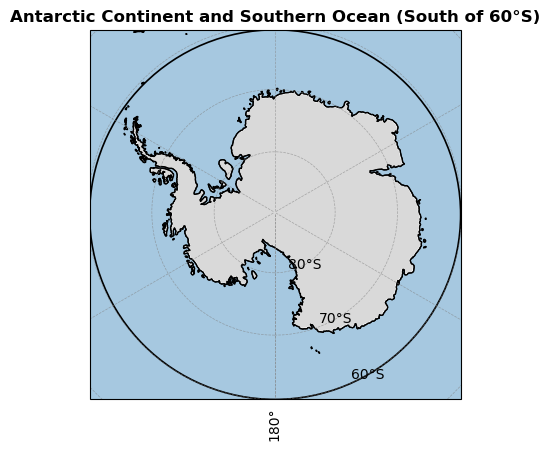

In [28]:
fig = plt.figure(figsize=(8, 8), dpi=150)
plt.figure() 
ax = plt.axes(projection=ccrs.SouthPolarStereo()) 
ax.coastlines()
# Set extent (from 60°S to pole)
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
# Add features with styling
ax.add_feature(cfeature.LAND, facecolor='#d9d9d9')
ax.add_feature(cfeature.OCEAN, facecolor='#a6c8e0')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Gridlines
gl = ax.gridlines(draw_labels=True,
                  linewidth=0.5,
                  color='gray',
                  alpha=0.6,
                  linestyle='--')

gl.top_labels = False
gl.right_labels = False

# Make circular boundary for a clean polar look
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = plt.Circle((0.5, 0.5), 0.5, transform=ax.transAxes,
                    facecolor='none', edgecolor='black', linewidth=1.2)
ax.add_patch(circle)

# Title
plt.title("Antarctic Continent and Southern Ocean (South of 60°S)",
          fontsize=12, weight='bold')

plt.show()

### Exercise 2 

In [35]:
geolocator = Nominatim(user_agent='educational') # nominatim is a free service and requires an identificative agent
CT = geolocator.geocode('Cape Town') 
SANAE = geolocator.geocode('SANAE IV')
print(type(CT))
print(CT,CT.point)
print(SANAE,SANAE.point)
print('The distance is ',geodesic(CT.point,SANAE.point).km,' km')


<class 'geopy.location.Location'>
Cape Town, City of Cape Town, Western Cape, 8001, South Africa 33 55m 43.7884s S, 18 25m 1.99092s E
SANAE IV 71 40m 25.2163s S, 2 49m 43.7081s W
The distance is  4382.159276626553  km


[Location(Walvis Bay, Erongo Region, 13013, Namibia, (-22.9557607, 14.5071125, 0.0)), Location(Cape Town, City of Cape Town, Western Cape, 8001, South Africa, (-33.9288301, 18.4172197, 0.0)), Location(Rio de Janeiro, Southeast Region, Brazil, (-22.9110137, -43.2093727, 0.0)), Location(Montevideo, Uruguay, (-34.9058916, -56.1913095, 0.0))]


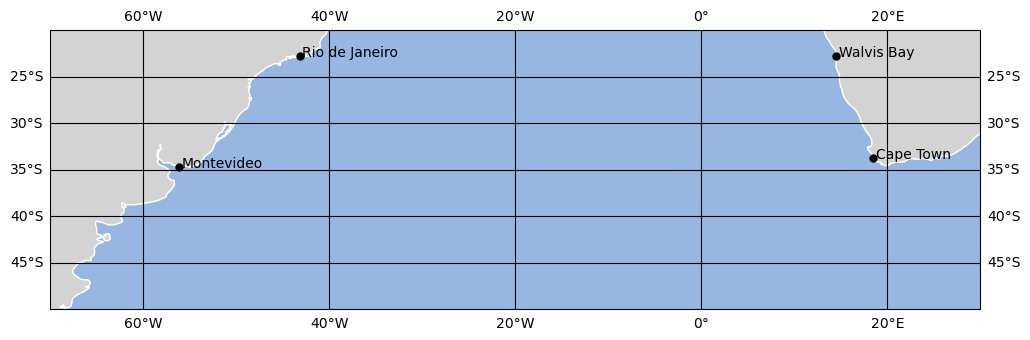

In [38]:
# a map of the Mediterranean, with a few places
extent = [-70, 30, -50, -20]
central_lon = np.mean(extent[:2])
central_lat = np.mean(extent[2:])

place = ['Walvis Bay', 'Cape Town', 'Rio de Janeiro', 'Montevideo']
address = []
for p in place:
    loc = geolocator.geocode(p,language="en")
    address.append(loc)
print(address)

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.coastlines(color='white')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND, color='lightgray')
ax.gridlines(draw_labels=True, color='black')
for p in range(len(place)):
    ax.plot(address[p].longitude,address[p].latitude,'ko',markersize=5,transform=ccrs.Geodetic())
    ax.text(address[p].longitude+0.3,address[p].latitude,place[p],transform=ccrs.Geodetic())
